#Decoding Hit Songs: What Musical Features Are Associated with Billboard Success?

## Project Overview

This project investigates whether Spotify audio features are associated with Billboard chart success. It does not attempt to establish that particular musical characteristics cause commercial success.

## Import Libraries



In [ ]:
# Install/import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

pd.set_option("display.max_columns", None)

sns.set_theme(style="whitegrid")

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving dataset.csv to dataset (1).csv
Saving hot100.csv to hot100.csv


## Load Data

In [ ]:
# Load datasets

spotify = pd.read_csv("dataset.csv")
billboard = pd.read_csv("hot100.csv")

print("Spotify dataset shape:", spotify.shape)
print("Billboard dataset shape:", billboard.shape)

Spotify dataset shape: (114000, 21)
Billboard dataset shape: (354958, 8)


In [ ]:
# Inspect Spotify dataset

print("SPOTIFY DATASET")
print("=" * 50)

display(spotify.head())

print("\nColumns:")
print(spotify.columns.tolist())

print("\nData types:")
display(spotify.dtypes)

SPOTIFY DATASET


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic



Columns:
['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']

Data types:


,0
Unnamed: 0,int64
track_id,object
artists,object
album_name,object
track_name,object
popularity,int64
duration_ms,int64
explicit,bool
danceability,float64
energy,float64


In [ ]:
# Inspect Billboard dataset

print("BILLBOARD DATASET")
print("=" * 50)

display(billboard.head())

print("\nColumns:")
print(billboard.columns.tolist())

print("\nData types:")
display(billboard.dtypes)

BILLBOARD DATASET


,Date,Song,Artist,Rank,Last Week,Peak Position,Weeks in Charts,Image URL
0,1958-07-30,Poor Little Fool,Ricky Nelson,1,-,1,1,NaN
1,1958-07-30,Patricia,Perez Prado And His Orchestra,2,-,2,1,NaN
2,1958-07-30,Splish Splash,Bobby Darin,3,-,3,1,NaN
3,1958-07-30,Hard Headed Woman,Elvis Presley With The Jordanaires,4,-,4,1,https://charts-static.billboard.com/img/1958/0...
4,1958-07-30,When,Kalin Twins,5,-,5,1,NaN



Columns:
['Date', 'Song', 'Artist', 'Rank', 'Last Week', 'Peak Position', 'Weeks in Charts', 'Image URL']

Data types:


,0
Date,object
Song,object
Artist,object
Rank,int64
Last Week,object
Peak Position,int64
Weeks in Charts,int64
Image URL,object


In [ ]:
# Check missing values and duplicates

print("SPOTIFY")
print("=" * 50)
print("Duplicate rows:", spotify.duplicated().sum())
display(spotify.isna().sum().sort_values(ascending=False))

print("\nBILLBOARD")
print("=" * 50)
print("Duplicate rows:", billboard.duplicated().sum())
display(billboard.isna().sum().sort_values(ascending=False))

SPOTIFY
Duplicate rows: 0


,0
artists,1
track_name,1
album_name,1
Unnamed: 0,0
track_id,0
popularity,0
duration_ms,0
explicit,0
danceability,0
energy,0



BILLBOARD
Duplicate rows: 0


,0
Image URL,124215
Date,0
Artist,0
Song,0
Rank,0
Last Week,0
Peak Position,0
Weeks in Charts,0


## Data Exploration

##  Data Cleaning

In [ ]:
# Create working copies

spotify_clean = spotify.copy()
billboard_clean = billboard.copy()

# Remove unnecessary Spotify index column
spotify_clean = spotify_clean.drop(columns=["Unnamed: 0"])

# Convert Billboard date to datetime
billboard_clean["Date"] = pd.to_datetime(billboard_clean["Date"])

# Convert Billboard numeric columns
billboard_clean["Rank"] = pd.to_numeric(billboard_clean["Rank"], errors="coerce")
billboard_clean["Peak Position"] = pd.to_numeric(
    billboard_clean["Peak Position"], errors="coerce"
)
billboard_clean["Weeks in Charts"] = pd.to_numeric(
    billboard_clean["Weeks in Charts"], errors="coerce"
)

print("Spotify shape:", spotify_clean.shape)
print("Billboard shape:", billboard_clean.shape)

display(billboard_clean.head())

Spotify shape: (114000, 20)
Billboard shape: (354958, 8)


,Date,Song,Artist,Rank,Last Week,Peak Position,Weeks in Charts,Image URL
0,1958-07-30,Poor Little Fool,Ricky Nelson,1,-,1,1,NaN
1,1958-07-30,Patricia,Perez Prado And His Orchestra,2,-,2,1,NaN
2,1958-07-30,Splish Splash,Bobby Darin,3,-,3,1,NaN
3,1958-07-30,Hard Headed Woman,Elvis Presley With The Jordanaires,4,-,4,1,https://charts-static.billboard.com/img/1958/0...
4,1958-07-30,When,Kalin Twins,5,-,5,1,NaN


In [ ]:
# Remove unused Billboard column
billboard_clean = billboard_clean.drop(columns=["Image URL"])

print(billboard_clean.columns.tolist())

['Date', 'Song', 'Artist', 'Rank', 'Last Week', 'Peak Position', 'Weeks in Charts']


## Billboard Song-Level Dataset

###Billboard Song-Level Aggregation

The Billboard dataset contains weekly chart observations, meaning the same song appears multiple times as it remains on the Hot 100. To avoid treating repeated weekly observations as independent songs, the dataset is aggregated to song level. For each song-artist combination, the analysis retains the best chart position, total weeks observed, and chart date range.

In [ ]:
# Aggregate weekly Billboard observations to song level

billboard_songs = (
    billboard_clean
    .groupby(["Song", "Artist"], as_index=False)
    .agg(
        peak_position=("Peak Position", "min"),
        weeks_on_chart=("Weeks in Charts", "max"),
        first_chart_date=("Date", "min"),
        last_chart_date=("Date", "max")
    )
)

# Create success indicators
billboard_songs["top_10"] = billboard_songs["peak_position"] <= 10
billboard_songs["number_one"] = billboard_songs["peak_position"] == 1

print("Unique Billboard songs:", len(billboard_songs))

display(billboard_songs.head())

Unique Billboard songs: 32599


,Song,Artist,peak_position,weeks_on_chart,first_chart_date,last_chart_date,top_10,number_one
0,"""(Girls, Girls, Girls) Made To Love""",Eddie Hodges,14,11,1962-06-20,1962-08-29,False,False
1,"""(If You Cry) True Love, True Love""",The Drifters,33,11,1959-10-28,1960-01-06,False,False
2,"""(Mama Come Quick, and Bring Your) Lickin' Stick""",George Torrence & The Naturals,91,2,1968-02-14,1968-02-21,False,False
3,"""(Shake, Shake, Shake) Shake Your Booty""",KC And The Sunshine Band,1,21,1976-07-07,1976-11-24,True,True
4,"""(The Story Of) Woman, Love And A Man (Part 1)""",Tony Clarke,88,1,1964-03-11,1964-03-11,False,False


In [ ]:
# Basic Billboard song-level summary

print("Number of unique songs:", len(billboard_songs))
print("Top 10 songs:", billboard_songs["top_10"].sum())
print("#1 songs:", billboard_songs["number_one"].sum())

print("\nPeak position summary:")
display(billboard_songs["peak_position"].describe())

print("\nWeeks on chart summary:")
display(billboard_songs["weeks_on_chart"].describe())

Number of unique songs: 32599
Top 10 songs: 5297
#1 songs: 1194

Peak position summary:


,peak_position
count,32599.000000
mean,47.038928
std,30.364626
min,1.000000
25%,19.000000
50%,47.000000
75%,73.000000
max,100.000000



Weeks on chart summary:


,weeks_on_chart
count,32599.000000
mean,10.887052
std,8.755008
min,1.000000
25%,4.000000
50%,9.000000
75%,16.000000
max,112.000000


standarising the names beofre integration

In [ ]:
import re

def clean_text(text):
    """Standardise text for matching across datasets."""
    if pd.isna(text):
        return ""

    text = str(text).lower().strip()

    # Remove punctuation
    text = re.sub(r"[^a-z0-9\s]", "", text)

    # Collapse multiple spaces
    text = re.sub(r"\s+", " ", text)

    return text


# Create standardised matching columns

spotify_clean["artist_match"] = spotify_clean["artists"].apply(clean_text)
spotify_clean["track_match"] = spotify_clean["track_name"].apply(clean_text)

billboard_songs["artist_match"] = billboard_songs["Artist"].apply(clean_text)
billboard_songs["track_match"] = billboard_songs["Song"].apply(clean_text)

##Spotify–Billboard Data Integration

In [ ]:
# First-pass exact match on cleaned artist + song names

merged_test = billboard_songs.merge(
    spotify_clean,
    on=["artist_match", "track_match"],
    how="inner",
    suffixes=("_billboard", "_spotify")
)

print("Billboard songs:", len(billboard_songs))
print("Spotify tracks:", len(spotify_clean))
print("Matched songs:", len(merged_test))

match_rate = len(merged_test) / len(billboard_songs) * 100

print(f"Initial Billboard match rate: {match_rate:.2f}%")

Billboard songs: 32599
Spotify tracks: 114000
Matched songs: 5442
Initial Billboard match rate: 16.69%


investigating duplicates

In [ ]:
# Check for repeated artist + track combinations in Spotify

spotify_song_counts = (
    spotify_clean
    .groupby(["artist_match", "track_match"])
    .size()
    .reset_index(name="count")
)

print("Unique artist-track combinations:", len(spotify_song_counts))
print("Total Spotify tracks:", len(spotify_clean))
print("Artist-track combinations appearing more than once:",
      (spotify_song_counts["count"] > 1).sum())

display(
    spotify_song_counts[spotify_song_counts["count"] > 1]
    .sort_values("count", ascending=False)
    .head(20)
)

Unique artist-track combinations: 78529
Total Spotify tracks: 114000
Artist-track combinations appearing more than once: 16435


,artist_match,track_match,count
0,,,253
55,,,170
14069,chuck berry,run rudolph run,151
49063,my little airport,,92
33395,jay chou,,89
20528,eason chan,,78
68414,the beach boys,little saint nick 1991 remix,76
11178,burna boy,last last,75
50921,nogizaka46,,71
62448,seiko matsuda,,70


In [ ]:
# Inspect repeated artist + track combinations

spotify_duplicates = spotify_clean.merge(
    spotify_song_counts[spotify_song_counts["count"] > 1][
        ["artist_match", "track_match"]
    ],
    on=["artist_match", "track_match"],
    how="inner"
)

display(
    spotify_duplicates[
        [
            "artists",
            "track_name",
            "track_genre",
            "popularity",
            "track_id"
        ]
    ].head(30)
)

,artists,track_name,track_genre,popularity,track_id
0,Gen Hoshino,Comedy,acoustic,73,5SuOikwiRyPMVoIQDJUgSV
1,Ben Woodward,Ghost - Acoustic,acoustic,55,4qPNDBW1i3p13qLCt0Ki3A
2,Kina Grannis,Can't Help Falling In Love,acoustic,71,6lfxq3CG4xtTiEg7opyCyx
3,Chord Overstreet,Hold On,acoustic,82,5vjLSffimiIP26QG5WcN2K
4,Tyrone Wells,Days I Will Remember,acoustic,58,01MVOl9KtVTNfFiBU9I7dc
5,A Great Big World;Christina Aguilera,Say Something,acoustic,74,6Vc5wAMmXdKIAM7WUoEb7N
6,Jason Mraz,I'm Yours,acoustic,80,1EzrEOXmMH3G43AXT1y7pA
7,Jason Mraz;Colbie Caillat,Lucky,acoustic,74,0IktbUcnAGrvD03AWnz3Q8
8,Ross Copperman,Hunger,acoustic,56,7k9GuJYLp2AzqokyEdwEw2
9,Zack Tabudlo,Give Me Your Forever,acoustic,74,4mzP5mHkRvGxdhdGdAH7EJ


In [ ]:
# Select one Spotify record per artist-track combination
# using the highest Spotify popularity as the representative record.

spotify_song_level = (
    spotify_clean
    .sort_values("popularity", ascending=False)
    .drop_duplicates(
        subset=["artist_match", "track_match"],
        keep="first"
    )
    .copy()
)

print("Original Spotify rows:", len(spotify_clean))
print("Unique artist-track combinations:", len(spotify_song_level))

print(
    f"Rows removed during deduplication: "
    f"{len(spotify_clean) - len(spotify_song_level)}"
)

display(
    spotify_song_level[
        [
            "artists",
            "track_name",
            "track_genre",
            "popularity",
            "danceability",
            "energy",
            "loudness",
            "valence",
            "tempo"
        ]
    ].head(10)
)

Original Spotify rows: 114000
Unique artist-track combinations: 78529
Rows removed during deduplication: 35471


,artists,track_name,track_genre,popularity,danceability,energy,loudness,valence,tempo
81051,Sam Smith;Kim Petras,Unholy (feat. Kim Petras),pop,100,0.714,0.472,-7.375,0.238,131.121
51664,Bizarrap;Quevedo,"Quevedo: Bzrp Music Sessions, Vol. 52",hip-hop,99,0.621,0.782,-5.548,0.550,128.033
89411,Manuel Turizo,La Bachata,reggaeton,98,0.835,0.679,-5.329,0.850,124.980
30003,David Guetta;Bebe Rexha,I'm Good (Blue),edm,98,0.561,0.965,-3.673,0.304,128.040
88405,Bad Bunny;Chencho Corleone,Me Porto Bonito,reggae,97,0.911,0.712,-5.105,0.425,92.005
68304,Bad Bunny,Tití Me Preguntó,latino,97,0.650,0.715,-5.198,0.187,106.672
20000,Chris Brown,Under The Influence,dance,96,0.733,0.690,-5.529,0.310,116.992
79000,OneRepublic,I Ain't Worried,piano,96,0.704,0.797,-5.927,0.825,139.994
68359,Bad Bunny,Efecto,latino,96,0.801,0.475,-8.797,0.234,98.047
81052,Harry Styles,As It Was,pop,95,0.520,0.731,-5.338,0.662,173.930


In [ ]:
# Verify Spotify now has one row per artist-track combination

duplicate_check = (
    spotify_song_level
    .duplicated(subset=["artist_match", "track_match"])
    .sum()
)

print("Remaining duplicate artist-track combinations:", duplicate_check)

Remaining duplicate artist-track combinations: 0


In [ ]:
# Retry the exact cleaned-name match

merged_exact = billboard_songs.merge(
    spotify_song_level,
    on=["artist_match", "track_match"],
    how="inner",
    suffixes=("_billboard", "_spotify")
)

print("Billboard songs:", len(billboard_songs))
print("Spotify song-level records:", len(spotify_song_level))
print("Exact matched songs:", len(merged_exact))

match_rate = len(merged_exact) / len(billboard_songs) * 100

print(f"Exact match rate: {match_rate:.2f}%")

Billboard songs: 32599
Spotify song-level records: 78529
Exact matched songs: 2166
Exact match rate: 6.64%


In [ ]:
# Inspect matched songs

display(
    merged_exact[
        [
            "Song",
            "Artist",
            "peak_position",
            "weeks_on_chart",
            "track_name",
            "artists",
            "track_genre",
            "popularity"
        ]
    ].head(30)
)

,Song,Artist,peak_position,weeks_on_chart,track_name,artists,track_genre,popularity
0,"""1, 2, 3, 4""",Plain White T's,34,20,"1, 2, 3, 4",Plain White T's,punk,42
1,"""Break Up With Your Girlfriend, I'm Bored""",Ariana Grande,2,20,"break up with your girlfriend, i'm bored",Ariana Grande,dance,78
2,"""Burn, Burn, Burn""",Zach Bryan,93,3,"Burn, Burn, Burn",Zach Bryan,country,0
3,"""Can't Get Enough Of Your Love, Babe""",Barry White,1,12,"Can't Get Enough Of Your Love, Babe",Barry White,disco,68
4,"""Come On, Let's Go""",Ritchie Valens,42,13,"Come On, Let's Go",Ritchie Valens,rockabilly,58
5,"""Courtesy Of The Red, White And Blue (The Angr...",Toby Keith,11,22,"Courtesy Of The Red, White And Blue (The Angry...",Toby Keith,country,0
6,"""Dance, Dance""",Fall Out Boy,9,31,"Dance, Dance",Fall Out Boy,emo,77
7,"""Dance, Dance, Dance""",The Beach Boys,8,11,"Dance, Dance, Dance",The Beach Boys,psych-rock,26
8,"""Gone, Gone, Gone""",Phillip Phillips,24,30,"Gone, Gone, Gone",Phillip Phillips,folk,68
9,"""Green, Green Grass Of Home""",Tom Jones,11,12,Green Green Grass Of Home,Tom Jones,british,40


In [ ]:
# Examine the time coverage of matched songs

merged_exact["chart_year"] = (
    pd.to_datetime(merged_exact["first_chart_date"])
    .dt.year
)

print("Earliest matched song:", merged_exact["chart_year"].min())
print("Latest matched song:", merged_exact["chart_year"].max())

print("\nMatched songs by decade:")

decades = (
    merged_exact
    .assign(
        decade=(merged_exact["chart_year"] // 10) * 10
    )
    .groupby("decade")
    .size()
    .reset_index(name="songs")
)

display(decades)

Earliest matched song: 1958
Latest matched song: 2026

Matched songs by decade:


,decade,songs
0,1950,36
1,1960,212
2,1970,245
3,1980,304
4,1990,234
5,2000,382
6,2010,514
7,2020,239


In [ ]:
# Matched songs by year

year_counts = (
    merged_exact
    .groupby("chart_year")
    .size()
    .reset_index(name="songs")
    .sort_values("chart_year")
)

display(year_counts)

,chart_year,songs
0,1958,16
1,1959,20
2,1960,22
3,1961,24
4,1962,14
...,...,...
64,2022,84
65,2023,5
66,2024,2
67,2025,2


In [ ]:
# Check the distribution of chart success in our matched sample

print("Matched songs:", len(merged_exact))
print("Top 10 hits:", merged_exact["top_10"].sum())
print("#1 hits:", merged_exact["number_one"].sum())

print("\nTop 10 proportion:")
print(f"{merged_exact['top_10'].mean() * 100:.1f}%")

Matched songs: 2166
Top 10 hits: 801
#1 hits: 253

Top 10 proportion:
37.0%


###Analytical Dataset

The Billboard dataset spans multiple decades, while Spotify audio-feature availability is uneven across historical releases. To focus the analysis on the modern music landscape and avoid drawing conclusions from very small recent-year samples, the primary analysis uses Billboard songs that charted between 2000 and 2022 and could be reliably matched to Spotify audio features.

In [ ]:
# Create the final analytical dataset

analysis_df = merged_exact[
    (merged_exact["chart_year"] >= 2000) &
    (merged_exact["chart_year"] <= 2022)
].copy()

print("Final analytical sample:", len(analysis_df))
print(
    "Year range:",
    analysis_df["chart_year"].min(),
    "to",
    analysis_df["chart_year"].max()
)

print("\nTop 10 songs:", analysis_df["top_10"].sum())
print("#1 songs:", analysis_df["number_one"].sum())

print("\nTop 10 proportion:")
print(f"{analysis_df['top_10'].mean() * 100:.1f}%")

Final analytical sample: 1124
Year range: 2000 to 2022

Top 10 songs: 272
#1 songs: 68

Top 10 proportion:
24.2%


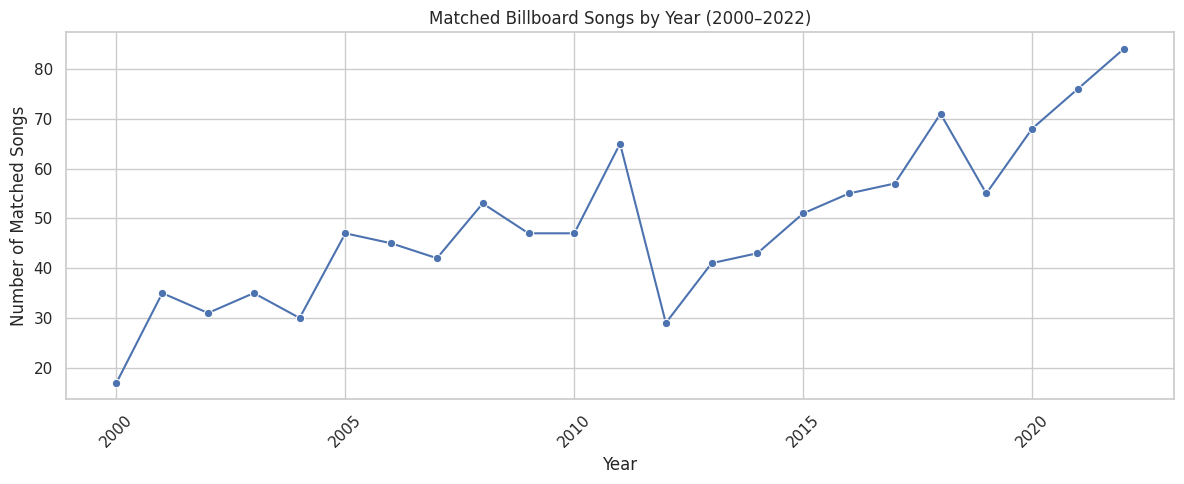

In [ ]:
# Number of matched songs by year

songs_by_year = (
    analysis_df
    .groupby("chart_year")
    .size()
    .reset_index(name="songs")
)

plt.figure(figsize=(12, 5))

sns.lineplot(
    data=songs_by_year,
    x="chart_year",
    y="songs",
    marker="o"
)

plt.title("Matched Billboard Songs by Year (2000–2022)")
plt.xlabel("Year")
plt.ylabel("Number of Matched Songs")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [ ]:
# Summary statistics for Spotify audio features

audio_features = [
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo"
]

display(
    analysis_df[audio_features]
    .describe()
    .T
    .round(3)
)

,count,mean,std,min,25%,50%,75%,max
danceability,1124.0,0.596,0.149,0.153,0.489,0.592,0.701,0.965
energy,1124.0,0.691,0.188,0.116,0.568,0.720,0.843,0.996
loudness,1124.0,-5.843,2.271,-16.661,-6.888,-5.432,-4.240,-1.190
speechiness,1124.0,0.075,0.079,0.022,0.034,0.047,0.076,0.743
acousticness,1124.0,0.187,0.244,0.000,0.008,0.073,0.267,0.969
instrumentalness,1124.0,0.010,0.061,0.000,0.000,0.000,0.000,0.985
liveness,1124.0,0.176,0.133,0.020,0.095,0.122,0.216,0.956
valence,1124.0,0.485,0.220,0.037,0.308,0.484,0.649,0.970
tempo,1124.0,124.082,29.382,48.718,100.050,123.325,144.020,200.085


###Top 10 vs Other Billboard Songs

To investigate whether musical characteristics differ between highly successful and other charting songs, songs are divided into two groups based on their best Billboard position. A Top 10 song is defined as a song whose peak position was 10 or higher in chart performance (i.e. peak position ≤ 10).

In [ ]:
# Compare average audio features between Top 10 and non-Top 10 songs

feature_comparison = (
    analysis_df
    .groupby("top_10")[audio_features]
    .mean()
    .T
)

feature_comparison.columns = ["Non-Top 10", "Top 10"]

display(feature_comparison.round(3))

,Non-Top 10,Top 10
danceability,0.585,0.631
energy,0.692,0.689
loudness,-5.891,-5.694
speechiness,0.075,0.076
acousticness,0.188,0.185
instrumentalness,0.011,0.007
liveness,0.176,0.177
valence,0.480,0.499
tempo,124.695,122.165


/tmp/ipykernel_2785/848214692.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["No", "Yes"])
/tmp/ipykernel_2785/848214692.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["No", "Yes"])
/tmp/ipykernel_2785/848214692.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["No", "Yes"])
/tmp/ipykernel_2785/848214692.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["No", "Yes"])
/tmp/ipykernel_2785/848214692.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["No", "Ye

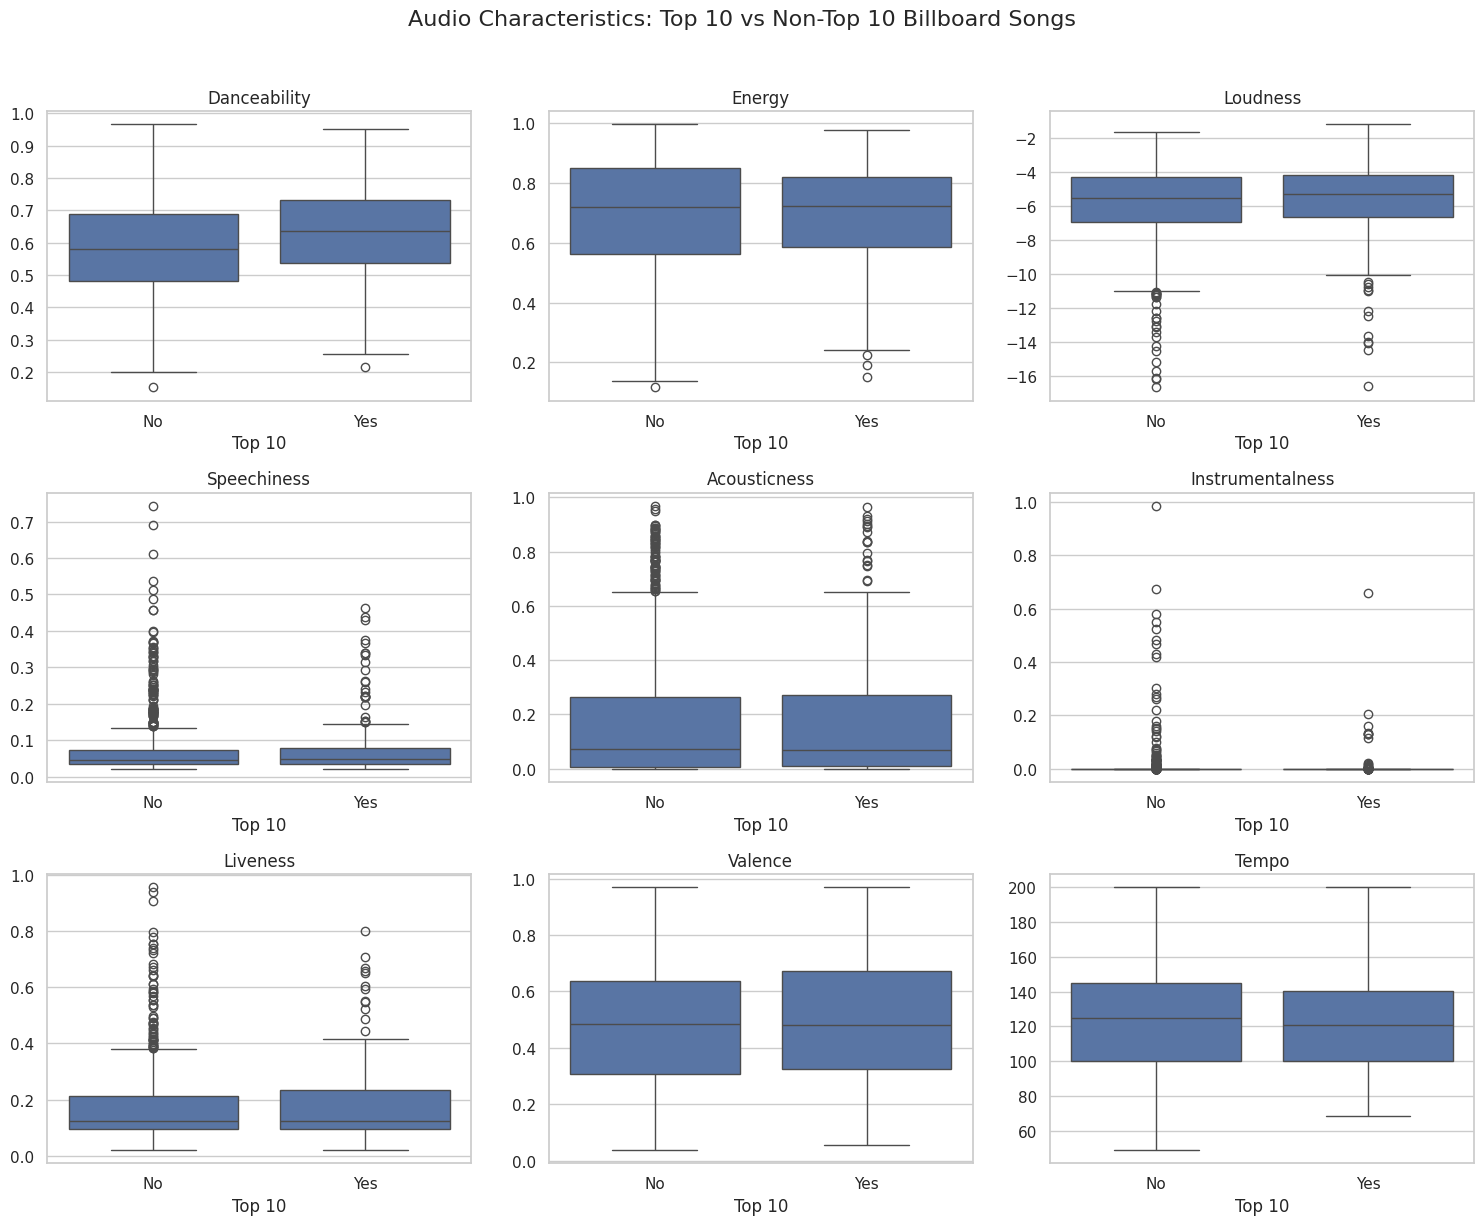

In [ ]:
# Visual comparison of audio features

fig, axes = plt.subplots(3, 3, figsize=(15, 12))

for ax, feature in zip(axes.flatten(), audio_features):

    sns.boxplot(
        data=analysis_df,
        x="top_10",
        y=feature,
        ax=ax
    )

    ax.set_title(feature.replace("_", " ").title())
    ax.set_xlabel("Top 10")
    ax.set_ylabel("")

    ax.set_xticklabels(["No", "Yes"])

plt.suptitle(
    "Audio Characteristics: Top 10 vs Non-Top 10 Billboard Songs",
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()

In [ ]:
# Mann-Whitney U tests: Top 10 vs non-Top 10

statistical_results = []

for feature in audio_features:

    top10_values = analysis_df.loc[
        analysis_df["top_10"] == True,
        feature
    ].dropna()

    non_top10_values = analysis_df.loc[
        analysis_df["top_10"] == False,
        feature
    ].dropna()

    statistic, p_value = stats.mannwhitneyu(
        top10_values,
        non_top10_values,
        alternative="two-sided"
    )

    statistical_results.append({
        "feature": feature,
        "p_value": p_value,
        "significant_at_0.05": p_value < 0.05
    })

statistical_results_df = pd.DataFrame(statistical_results)

display(
    statistical_results_df
    .sort_values("p_value")
    .round(5)
)

,feature,p_value,significant_at_0.05
0,danceability,0.00000,True
5,instrumentalness,0.04660,True
3,speechiness,0.13671,False
2,loudness,0.14295,False
8,tempo,0.19537,False
7,valence,0.23339,False
4,acousticness,0.55721,False
1,energy,0.56154,False
6,liveness,0.95526,False


##Exploratory Analysis

## Statistical Analysis

## Trends Over Time

## Key Findings

##  A&R Implications

## Limitations